In [1]:
!pip install datasets


Load and Inspect the Data

In [4]:
from datasets import load_dataset
import pandas as pd

# Load the dataset (this loads all available splits)
dataset = load_dataset("cnamuangtoun/resume-job-description-fit")

# Combine all splits into a single pandas DataFrame
# (if there are multiple splits like 'train', 'test', etc.)
all_splits = []
for split in dataset.keys():
    df_split = dataset[split].to_pandas()
    all_splits.append(df_split)

# Concatenate all splits into one DataFrame
match_df1 = pd.concat(all_splits, ignore_index=True)

# Read CSV file
match_df2 = pd.read_csv("job_applicant_dataset.csv")


In [5]:
print(match_df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   resume_text           8000 non-null   object
 1   job_description_text  8000 non-null   object
 2   label                 8000 non-null   object
dtypes: object(3)
memory usage: 187.6+ KB
None


In [6]:
print(match_df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Applicant Name  10000 non-null  object
 1   Age                 10000 non-null  int64 
 2   Gender              10000 non-null  object
 3   Race                10000 non-null  object
 4   Ethnicity           10000 non-null  object
 5   Resume              10000 non-null  object
 6   Job Roles           10000 non-null  object
 7   Job Description     10000 non-null  object
 8   Best Match          10000 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 703.3+ KB
None


In [9]:
match_df1.head()

,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit


In [10]:
match_df2.head()

,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, N...",Fitness Coach,A Fitness Coach is responsible for helping cl...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medica...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling...",Financial Analyst,"As a Financial Analyst, you will be responsibl...",0
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,"Proficient in Budgeting, Supply Chain Optimiza...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
4,James Davis,49,Male,White/Caucasian,English,"Proficient in Logistics, Negotiation, Procurem...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1


In [14]:
# Check for missing values
print("=====Missing values match1========")
print(match_df1.isnull().sum())
print("=====Missing values match2========")
print(match_df2.isnull().sum())


=====Missing values match1========
resume_text             0
job_description_text    0
label                   0
dtype: int64
=====Missing values match2========
Job Applicant Name    0
Age                   0
Gender                0
Race                  0
Ethnicity             0
Resume                0
Job Roles             0
Job Description       0
Best Match            0
dtype: int64


In [23]:
# Count duplicate rows
num_duplicates = match_df1.duplicated().sum()
print(f"Number of duplicate rows in match1: {num_duplicates}")
num_duplicates = match_df2.duplicated().sum()
print(f"Number of duplicate rows in match2: {num_duplicates}")

# Remove duplicates
match_df1 = match_df1.drop_duplicates()
print(f"Duplicates removed. New shape: {match_df1.shape}")




Dropped empty-text rows: df1 0 rows, df2 0 rows


clean the datasets

In [21]:
import re

df1 = match_df1.copy()
df2 = match_df2.copy()

def clean_text_basic(text):
    """Lightweight cleaning: lowercase, remove emails/urls, punctuation (keeping basic alphanum), collapse spaces."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # remove emails
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    # remove urls
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # remove non-alphanumeric (preserve spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def token_set(s):
    """Return set of tokens for a cleaned string (simple split)."""
    if not isinstance(s, str) or s == "":
        return set()
    return set(s.split())

def jaccard(a,b):
    if (not a) and (not b):
        return 0.0
    inter = a.intersection(b)
    union = a.union(b)
    if not union:
        return 0.0
    return len(inter) / len(union)

df1_columns = [c.lower().strip() for c in df1.columns]
df1.columns = df1_columns

df2 = df2.rename(columns=lambda c: c.strip())
# rename known columns
rename_map_df2 = {}
for col in df2.columns:
    if col.lower() in ["resume", "resume_text", "resume_text "]:
        rename_map_df2[col] = "resume_text"
    if col.lower() in ["job description", "job_description", "job_description_text"]:
        rename_map_df2[col] = "job_description_text"
    if col.lower() in ["best match", "best_match", "bestmatch"]:
        rename_map_df2[col] = "label"
df2 = df2.rename(columns=rename_map_df2)

# Normalize df1 labels (strings like 'no fit', 'potential', 'good fit')
df1['label'] = df1['label'].astype(str).str.lower().str.strip()
# unify wording: remove extra spaces, replace multiple variants:
df1['label'] = df1['label'].replace({
    'no fit': 'no_fit',
    'no_fit': 'no_fit',
    'no-fit': 'no_fit',
    'good fit': 'good_fit',
    'good_fit': 'good_fit',
    'good-fit': 'good_fit',
    'potential': 'potential_fit',
    'potential fit': 'potential_fit',
    'potential_fit': 'potential_fit'
})


# Normalize df2 numeric labels (Best Match: 1 or 0) -> map to same strings
# Handle cases where label might already be string; convert ints to strings
def map_df2_label(x):
    if pd.isna(x):
        return 'no_fit'
    # if it's numeric
    try:
        if int(x) == 1:
            return 'good_fit'
        elif int(x) == 0:
            return 'no_fit'
    except Exception:
        pass
    s = str(x).lower().strip()
    if s in ['1', 'yes', 'true', 'good', 'good fit', 'good_fit']:
        return 'good_fit'
    if s in ['0', 'no', 'false', 'no fit', 'no_fit']:
        return 'no_fit'
    # fallback: treat anything else as 'potential_fit' if it contains 'potential'
    if 'potential' in s:
        return 'potential_fit'
    return s

df2['label'] = df2['label'].apply(map_df2_label)

In [29]:
# Verify label categories
print("\nLabel distribution df1:")
print(df1['label'].value_counts(dropna=False))
print("\nLabel distribution df2:")
print(df2['label'].value_counts(dropna=False))

# We'll map: no_fit=0, potential_fit=1, good_fit=2
label_map = {'no_fit': 0, 'potential_fit': 1, 'good_fit': 2}
df1['label_num'] = df1['label'].map(label_map).fillna(-1).astype(int)
df2['label_num'] = df2['label'].map(label_map).fillna(-1).astype(int)

print("\nLabel num distribution df1:")
print(df1['label_num'].value_counts())
print("\nLabel num distribution df2:")
print(df2['label_num'].value_counts())


Label distribution df1:
label
no_fit           3999
potential_fit    2000
good_fit         2000
Name: count, dtype: int64

Label distribution df2:
label
no_fit      5150
good_fit    4850
Name: count, dtype: int64

Label num distribution df1:
label_num
0    3999
1    2000
2    2000
Name: count, dtype: int64

Label num distribution df2:
label_num
0    5150
2    4850
Name: count, dtype: int64


In [24]:
for col in ['resume_text', 'job_description_text']:
    df1[col] = df1[col].apply(clean_text_basic)
    df2[col] = df2[col].apply(clean_text_basic)

In [25]:
# Quick sanity sample
print("\nSample cleaned df1 row:")
display(df1[['resume_text','job_description_text','label']].head(1))
print("\nSample cleaned df2 row:")
display(df2[['resume_text','job_description_text','label']].head(1))



Sample cleaned df1 row:


,resume_text,job_description_text,label
0,summaryhighly motivated sales associate with e...,net2source inc is an award winning total workf...,no_fit



Sample cleaned df2 row:


,resume_text,job_description_text,label
0,proficient in injury prevention motivation nut...,a fitness coach is responsible for helping cli...,no_fit


Feature Engineering

In [26]:
def add_text_features(df):
    # ensure we operate on a copy
    df = df.copy()
    # lengths
    df['resume_char_len'] = df['resume_text'].str.len()
    df['job_desc_char_len'] = df['job_description_text'].str.len()
    df['resume_word_count'] = df['resume_text'].apply(lambda x: len(x.split()))
    df['job_desc_word_count'] = df['job_description_text'].apply(lambda x: len(x.split()))
    # unique token counts
    df['resume_unique_tokens'] = df['resume_text'].apply(lambda t: len(set(t.split())))
    df['job_desc_unique_tokens'] = df['job_description_text'].apply(lambda t: len(set(t.split())))
    # token sets and overlap features (Jaccard & intersection count)
    # to save memory, compute on the fly with apply rowwise
    df['token_intersection_count'] = df.apply(lambda r: len(token_set(r['resume_text']).intersection(token_set(r['job_description_text']))), axis=1)
    df['token_jaccard'] = df.apply(lambda r: jaccard(token_set(r['resume_text']), token_set(r['job_description_text'])), axis=1)
    return df

df1 = add_text_features(df1)
df2 = add_text_features(df2)


In [27]:
df1.head()

,resume_text,job_description_text,label,resume_char_len,job_desc_char_len,resume_word_count,job_desc_word_count,resume_unique_tokens,job_desc_unique_tokens,token_intersection_count,token_jaccard
0,summaryhighly motivated sales associate with e...,net2source inc is an award winning total workf...,no_fit,6473,3714,898,571,415,342,64,0.092352
1,professional summarycurrently working with cat...,at salas obrien we tell our clients that were ...,no_fit,6409,3737,911,578,458,317,75,0.107143
2,summaryi started my construction career in jun...,schweitzer engineering laboratories sel infras...,no_fit,7170,3076,981,460,464,286,45,0.063830
3,summarycertified electrical foremanwith thirte...,mizick miller company inc is looking for a dyn...,no_fit,5596,1034,758,164,400,111,29,0.060166
4,summarywith extensive experience in business r...,life at capgemini capgemini supports all aspec...,no_fit,12703,5932,1885,894,575,455,114,0.124454


In [28]:
df2.head()

,Job Applicant Name,Age,Gender,Race,Ethnicity,resume_text,Job Roles,job_description_text,label,resume_char_len,job_desc_char_len,resume_word_count,job_desc_word_count,resume_unique_tokens,job_desc_unique_tokens,token_intersection_count,token_jaccard
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,proficient in injury prevention motivation nut...,Fitness Coach,a fitness coach is responsible for helping cli...,no_fit,285,584,40,89,37,64,9,0.097826
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,proficient in healthcare pharmacology medical ...,Physician,diagnose and treat illnesses prescribe medicat...,no_fit,288,442,39,59,36,52,11,0.142857
2,Sarah Martin,46,Female,White/Caucasian,Dutch,proficient in forecasting financial modelling ...,Financial Analyst,as a financial analyst you will be responsible...,no_fit,279,607,38,89,35,65,13,0.149425
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,proficient in budgeting supply chain optimizat...,Supply Chain Manager,a supply chain manager oversees the entire sup...,good_fit,275,583,37,87,33,62,10,0.117647
4,James Davis,49,Male,White/Caucasian,English,proficient in logistics negotiation procuremen...,Supply Chain Manager,a supply chain manager oversees the entire sup...,good_fit,284,583,39,87,36,62,9,0.101124


EDA

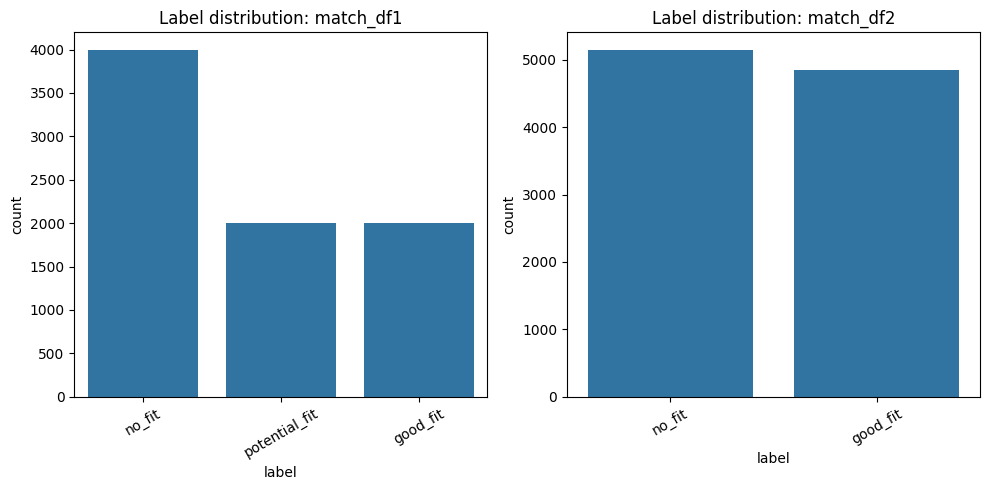

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# A) Label balance plots
def plot_label_balance(dfs, names):
    plt.figure(figsize=(10,5))
    for i, df in enumerate(dfs):
        ax = plt.subplot(1, len(dfs), i+1)
        sns.countplot(x='label', data=df, order=df['label'].value_counts().index)
        plt.title(f"Label distribution: {names[i]}")
        plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

plot_label_balance([df1, df2], ['match_df1', 'match_df2'])

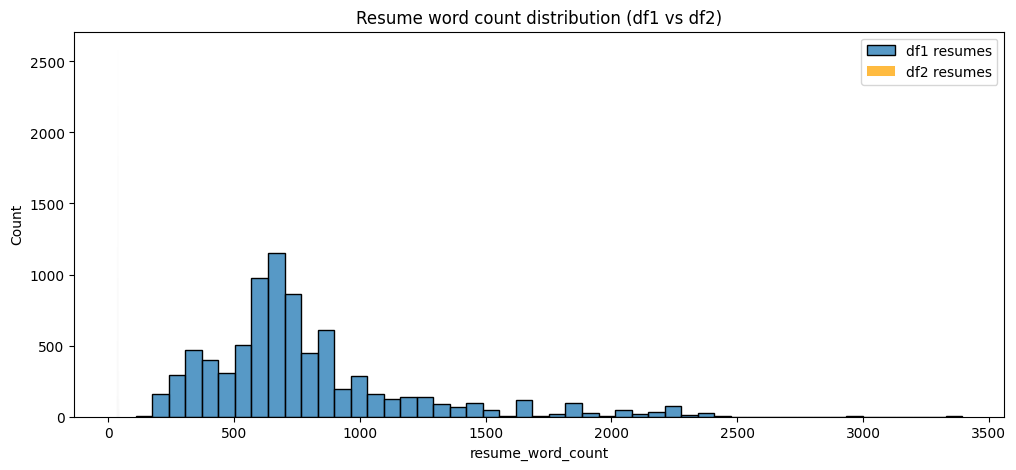

In [31]:
# B) Text length distributions (resumes)
plt.figure(figsize=(12,5))
sns.histplot(df1['resume_word_count'], bins=50, label='df1 resumes', kde=False, stat='count')
sns.histplot(df2['resume_word_count'], bins=50, label='df2 resumes', kde=False, stat='count', color='orange')
plt.legend()
plt.title("Resume word count distribution (df1 vs df2)")
plt.show()

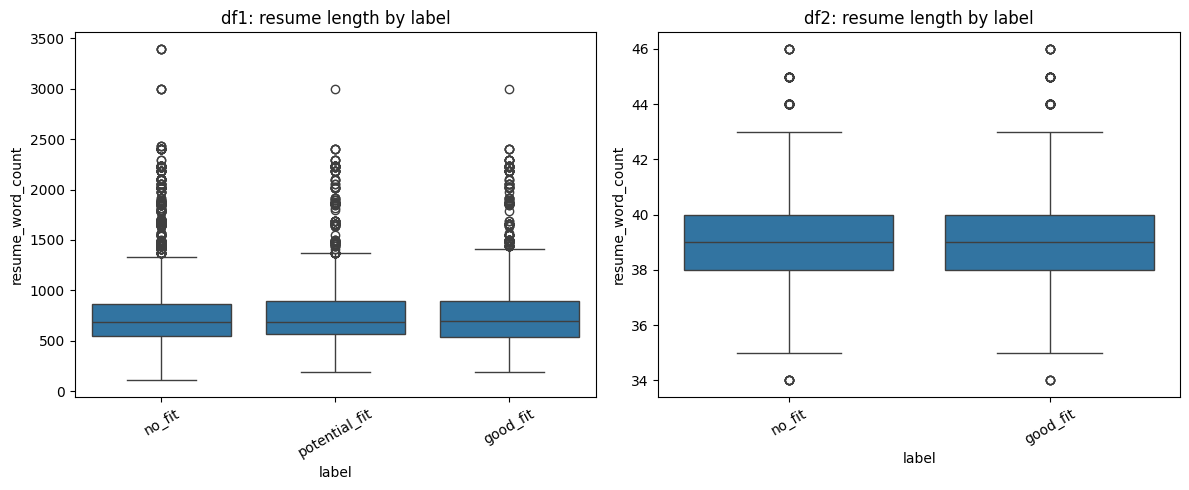

In [32]:
# C) Boxplot: resume length by label (df1 & df2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='label', y='resume_word_count', data=df1)
plt.title('df1: resume length by label')
plt.xticks(rotation=30)
plt.subplot(1,2,2)
sns.boxplot(x='label', y='resume_word_count', data=df2)
plt.title('df2: resume length by label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

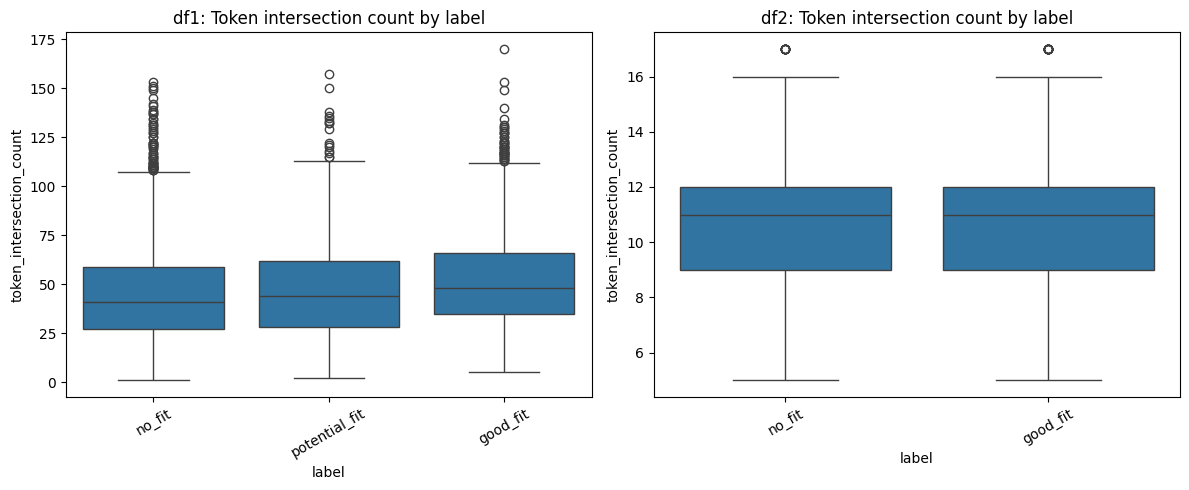

In [33]:
# D) Token overlap vs label (are good fits having higher overlap?)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='label', y='token_intersection_count', data=df1)
plt.title('df1: Token intersection count by label')
plt.xticks(rotation=30)
plt.subplot(1,2,2)
sns.boxplot(x='label', y='token_intersection_count', data=df2)
plt.title('df2: Token intersection count by label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

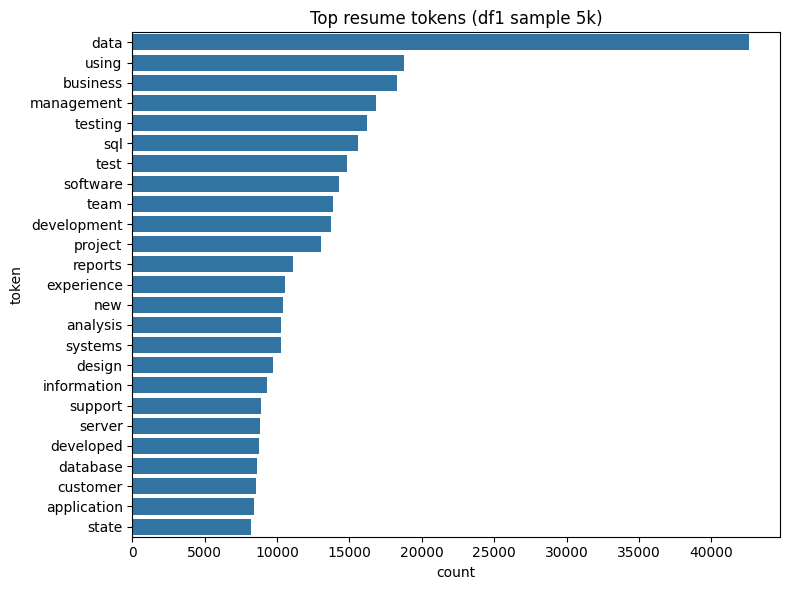

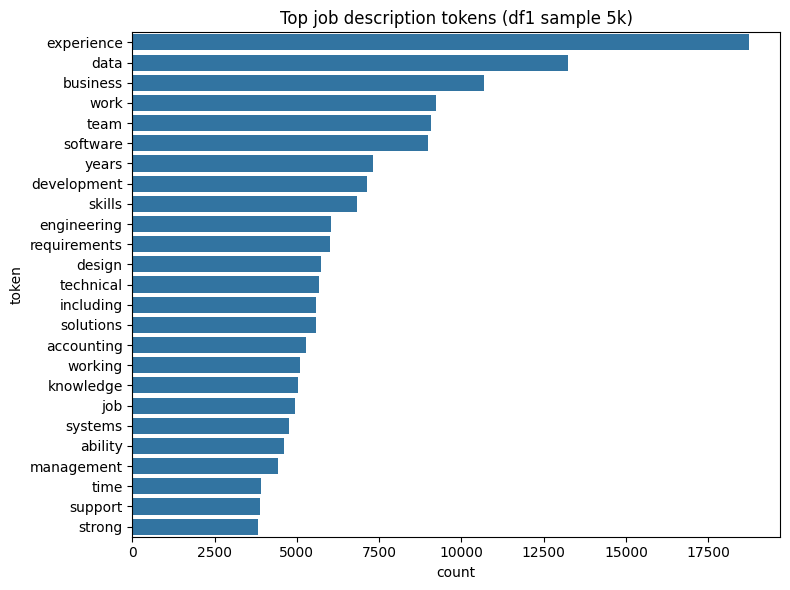

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
# E) Top tokens (words) in resumes and job descriptions using CountVectorizer
def plot_top_tokens(series_text, title, top_n=25, ngram_range=(1,1)):
    vect = CountVectorizer(stop_words='english', max_features=top_n, ngram_range=ngram_range)
    X = vect.fit_transform(series_text)
    sums = np.array(X.sum(axis=0)).flatten()
    tokens = vect.get_feature_names_out()
    df_top = pd.DataFrame({'token': tokens, 'count': sums}).sort_values('count', ascending=False)
    plt.figure(figsize=(8,6))
    sns.barplot(x='count', y='token', data=df_top)
    plt.title(title)
    plt.tight_layout()
    plt.show()
# Top tokens in resumes (combined sample) for speed
plot_top_tokens(df1['resume_text'].sample(min(5000, len(df1))), "Top resume tokens (df1 sample 5k)")
plot_top_tokens(df1['job_description_text'].sample(min(5000, len(df1))), "Top job description tokens (df1 sample 5k)")


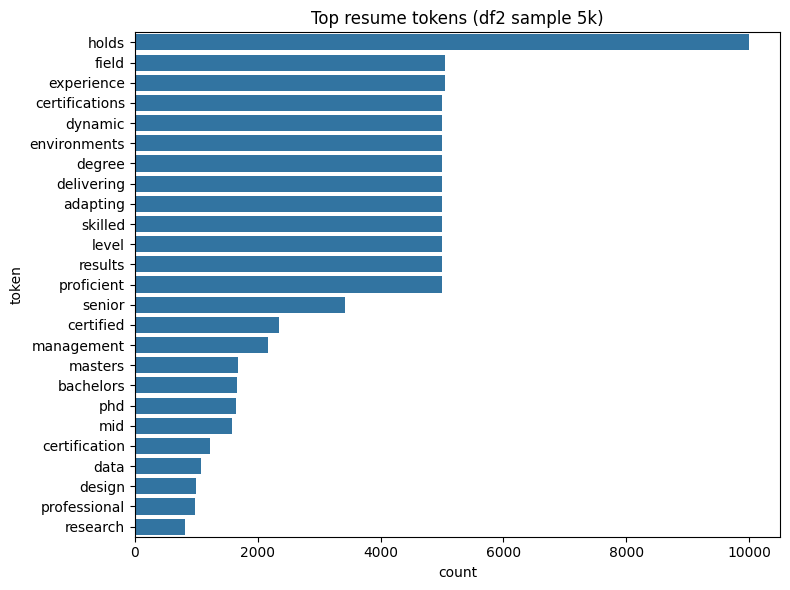

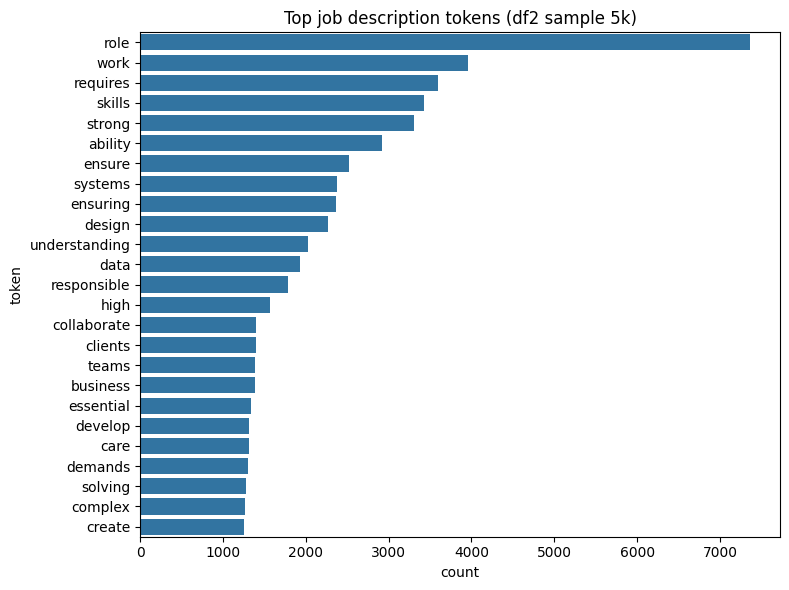

In [38]:
plot_top_tokens(df2['resume_text'].sample(min(5000, len(df2))), "Top resume tokens (df2 sample 5k)")
plot_top_tokens(df2['job_description_text'].sample(min(5000, len(df2))), "Top job description tokens (df2 sample 5k)")


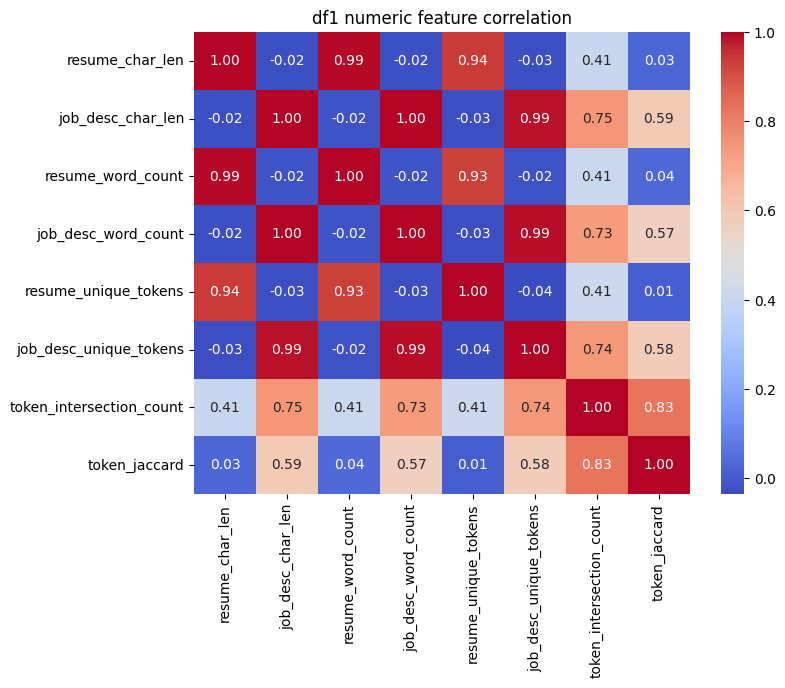

In [39]:
# F) Correlation heatmap for numerical features (small set)
num_cols = ['resume_char_len','job_desc_char_len','resume_word_count','job_desc_word_count',
            'resume_unique_tokens','job_desc_unique_tokens','token_intersection_count','token_jaccard']
corr_df1 = df1[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_df1, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('df1 numeric feature correlation')
plt.show()

In [41]:

# =================== 8) Combine datasets (optional) ===================
# Standardize column names and select only the canonical ones to concatenate
df1_sel = df1[['resume_text','job_description_text','label','label_num',
               'resume_word_count','job_desc_word_count','token_intersection_count','token_jaccard']].copy()
df2_sel = df2[['resume_text','job_description_text','label','label_num',
               'resume_word_count','job_desc_word_count','token_intersection_count','token_jaccard']].copy()

combined = pd.concat([df1_sel, df2_sel], ignore_index=True)
# Remove duplicates if exact same row exists across datasets
print("\nCombined shape before dedup:", combined.shape)
combined = combined.drop_duplicates().reset_index(drop=True)
print("Combined shape after dedup:", combined.shape)
print("Combined label counts:")
print(combined['label'].value_counts())

# Save cleaned outputs
df1.to_csv("match_df1_cleaned.csv", index=False)
df2.to_csv("match_df2_cleaned.csv", index=False)
combined.to_csv("candidate_job_matching_cleaned.csv", index=False)

print("\nSaved: match_df1_cleaned.csv, match_df2_cleaned.csv, candidate_job_matching_cleaned.csv")



Combined shape before dedup: (17999, 8)
Combined shape after dedup: (17996, 8)
Combined label counts:
label
no_fit           9149
good_fit         6847
potential_fit    2000
Name: count, dtype: int64

Saved: match_df1_cleaned.csv, match_df2_cleaned.csv, candidate_job_matching_cleaned.csv
